<a href="https://colab.research.google.com/github/k-loaeza/dsrp/blob/main/projectkloaeza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Exoplanets and the Search for Habitability

An exoplanet is a planet outside of our solar system. Out of the thousands of exoplanets identified, could some hold the key to life as we know it? How many planets are actually like Earth in size, distance to their host star, and physical characteristics? With over 6,000 confirmed exoplanets discovered to date, and thousands more candidates awaiting confirmation, the search for an Earth-like world has never been more active and data driven. What makes Earth uniquely suited for life comes down to a precise set of conditions scientists call the Goldilocks zone, which is the range of distances from a star, where the temperatures are neither too hot nor too cold for liquid water to exist. Earth sits at just the right distance from the Sun, is just the right size to hold an atmosphere, and maintains temperatures that allow life to thrive. Finding another planet that holds the same or similar conditions would be a significant discovery for humanity. This project invites students to use real NASA data to investigate that question.


In [3]:
url = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/NASA%20Exoplanet%20Data/nasa_exoplanets.csv'

data = pd.read_csv(url)
data.head()

,pl_name,hostname,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,discoverymethod,disc_year,sy_dist
0,Kepler-1167 b,Kepler-1167,1.710000,NaN,1.003934,0.01750,1419.0,4971.0,0.750,0.790,Transit,2016.0,820.905
1,Kepler-1740 b,Kepler-1740,3.323214,NaN,8.172400,0.07790,858.0,5705.0,0.905,0.943,Transit,2021.0,1061.770
2,Kepler-1581 b,Kepler-1581,0.800000,NaN,6.283855,0.06865,1108.0,6022.0,1.230,1.120,Transit,2016.0,493.175
3,Kepler-644 b,Kepler-644,3.150000,NaN,3.173917,0.04641,1655.0,6747.0,1.810,1.490,Transit,2016.0,1318.050
4,Kepler-1752 b,Kepler-1752,4.540605,NaN,56.358501,0.26980,419.0,5446.0,0.821,0.824,Transit,2021.0,962.888




*   pl_name = Exoplanet Name
*   host_name = Host Star
*   pl_rade = Radius of the exoplanet in units of Earth's radius
*   pl_masse = Mass of the exoplanet in units of Earth masses
*   pl_orbper = Orbital Period in Earth Years
*   pl_orbsmax = Longest radius of the elliptic orbit around the host star
*   pl_eqt = The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body
*   st_teff = Temperature of the star as modeled by a black body emitting the same total amount of electromagnetic radiation
*   st_rad = Radius of the host star in units of Sun's radius
*   st_mass = Mass of the host star in units of Sun masses
*   discovery_method = The method through which the planet was identified first
*   disc_year = The year in which the planet was first identified
*   sy_dist = Distance to the planetary system in parsecs




In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6298 non-null   object 
 1   hostname         6298 non-null   object 
 2   pl_rade          6248 non-null   float64
 3   pl_masse         2387 non-null   float64
 4   pl_orbper        5958 non-null   float64
 5   pl_orbsmax       5873 non-null   float64
 6   pl_eqt           4693 non-null   float64
 7   st_teff          6004 non-null   float64
 8   st_rad           5980 non-null   float64
 9   st_mass          6289 non-null   float64
 10  discoverymethod  6298 non-null   object 
 11  disc_year        6297 non-null   float64
 12  sy_dist          6271 non-null   float64
dtypes: float64(10), object(3)
memory usage: 639.8+ KB


,pl_rade,pl_masse,pl_orbper,pl_orbsmax,pl_eqt,st_teff,st_rad,st_mass,disc_year,sy_dist
count,6248.000000,2387.000000,5.958000e+03,5873.000000,4693.000000,6004.000000,5980.000000,6289.000000,6297.000000,6271.000000
mean,5.814146,807.870204,7.184593e+04,15.626989,914.662983,5392.629932,1.487920,0.933986,2017.190885,703.341417
std,5.407920,1585.552165,5.210495e+06,347.884017,462.876206,1731.489082,3.875038,0.387287,5.090143,1210.126435
min,0.309800,0.020000,9.070629e-02,0.004400,34.000000,415.000000,0.011500,0.009400,1992.000000,1.301190
25%,1.840000,11.115000,4.305389e+00,0.052300,569.000000,4897.000000,0.770000,0.770000,2014.000000,101.632000
50%,2.846633,156.053748,1.069293e+01,0.102200,823.000000,5542.000000,0.950000,0.940000,2016.000000,361.896000
75%,11.900000,722.348800,3.812277e+01,0.305000,1164.000000,5897.000000,1.240000,1.082000,2021.000000,824.499000
max,87.205870,9534.852210,4.020000e+08,19000.000000,4050.000000,57000.000000,88.475000,9.100000,2026.000000,8500.000000


In [5]:
# Standardizing column names
data.columns = ['pl_name', 'host_name', 'pl_rade', 'pl_masse', 'pl_orbper', 'pl_orbsmax',
       'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'disc_method',
       'disc_year', 'sy_dist']
data.head()
data[data['disc_year'].isnull()]
data['pl_name'].tail(10)
# Dropping rows with null values in disc year, sy dist, st mass,
dataD = data.dropna(subset=['disc_year', 'sy_dist', 'st_mass', 'pl_rade'])
data.info()
dataD.info()
data.isnull().sum()
dataD.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      6298 non-null   object 
 1   host_name    6298 non-null   object 
 2   pl_rade      6248 non-null   float64
 3   pl_masse     2387 non-null   float64
 4   pl_orbper    5958 non-null   float64
 5   pl_orbsmax   5873 non-null   float64
 6   pl_eqt       4693 non-null   float64
 7   st_teff      6004 non-null   float64
 8   st_rad       5980 non-null   float64
 9   st_mass      6289 non-null   float64
 10  disc_method  6298 non-null   object 
 11  disc_year    6297 non-null   float64
 12  sy_dist      6271 non-null   float64
dtypes: float64(10), object(3)
memory usage: 639.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 6215 entries, 0 to 6297
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      6215

,0
pl_name,0
host_name,0
pl_rade,0
pl_masse,3887
pl_orbper,326
pl_orbsmax,415
pl_eqt,1559
st_teff,284
st_rad,303
st_mass,0


Avoid working with the mass of the planet due to the missing values (so many)

Potential Research Questions:\
How does a planet's habitability relate to its distance from Earth?\
How does a planet's orbital period relate to its habitability?\
How does a planet's radius relate to its habitability?\
How do discovery methods relate to the discovery years?\
\* Habitability being defined as being as close to Earth values as possible \*\
Try making a regression that calculates whether or not a planet is likely to be habitable


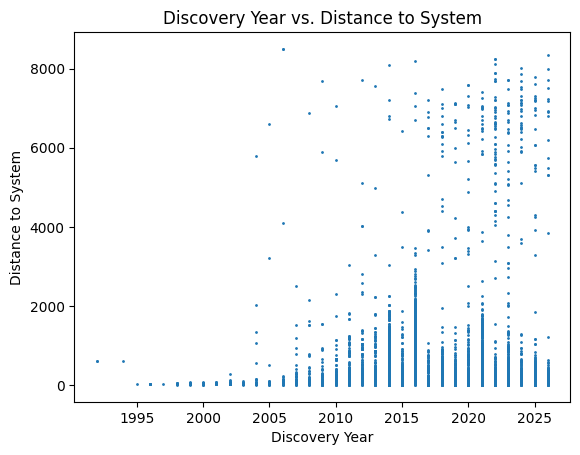

In [6]:
x = data['disc_year']
y = data['sy_dist']

plt.scatter(x, y, s=1)
plt.xlabel('Discovery Year')
plt.ylabel('Distance to System')
plt.title('Discovery Year vs. Distance to System')
plt.show()